# Experiment 2 — Stable DISCO Detection Curves Across Noise Families

The eval grid is `S_eval in [2,4,8,16,32,64]` with fixed ecosystem size and fixed attack strength.

In [ ]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

#lambda = variance = 1 for all these
#reference eval = 256

In [2]:
import sys

from pathlib import Path



PROJECT_ROOT = Path('..').resolve()

SCRIPT = PROJECT_ROOT / 'experiments' / 'exp16_stable_disco_detection_curves.py'

OUT_DIR = PROJECT_ROOT / 'results' / 'tables'

OUT_DIR.mkdir(parents=True, exist_ok=True)




python_candidates = [

    PROJECT_ROOT / '.venv' / 'bin' / 'python',

    PROJECT_ROOT.parent / '.venv' / 'bin' / 'python',

    Path(sys.executable),

]

PYTHON = str(next((p for p in python_candidates if p.exists()), Path(sys.executable)))



if not SCRIPT.exists():

    raise FileNotFoundError(f'Experiment script not found: {SCRIPT}')



RUN_CONFIGS = [

    {

        'label': 'gaussian',

        'family': 'gaussian',

        'extra': [],

        'output': str(OUT_DIR / 'exp16_detection_gaussian.csv'),

    },

    {

        'label': 'bounded_uniform',

        'family': 'bounded_uniform',

        'extra': [],

        'output': str(OUT_DIR / 'exp16_detection_bounded_uniform.csv'),

    },

    {

        'label': 'student_t_df3',

        'family': 'student_t',

        'extra': ['--sybil_noise_df', '3'],

        'output': str(OUT_DIR / 'exp16_detection_student_t.csv'),

    },

]



print('Using Python executable:', PYTHON)

print('Project root:', PROJECT_ROOT)

Using Python executable: /Users/victor/School/sem 8/special/.venv/bin/python
Project root: /Users/victor/School/sem 8/special/SISQED


In [ ]:
import os
import subprocess

# Set RUN_EXPERIMENTS=True to regenerate CSVs. Keep False to use existing results.
RUN_EXPERIMENTS = False

if RUN_EXPERIMENTS:
    # 1. CREATE A STRICT 1-THREAD-PER-PROCESS ENVIRONMENT
    env = os.environ.copy()
    env["OMP_NUM_THREADS"] = "1"
    env["OPENBLAS_NUM_THREADS"] = "1"
    env["MKL_NUM_THREADS"] = "1"
    env["VECLIB_MAXIMUM_THREADS"] = "1"
    env["NUMEXPR_NUM_THREADS"] = "1"

    for cfg in RUN_CONFIGS:
        cmd = [
            PYTHON, str(SCRIPT),
            '--trials', '50', # run the entire sim 50 times 
            '--n_fit', '20', # n fit
            '--n_eval', '24', # n eval
            '--s_fit', '12', # s fit
            '--s_eval_reference', '256', # baseline asymptotic. shoiuld maybe be higher
            '--n_honest', '8', # how many honest models
            '--dim', '8',
            '--sybil_noise_std', '0.30', # sybil noise stf
            '--sybil_noise_family', cfg['family'],
            '--output_file', cfg['output'],
        ] + cfg['extra']

        print('Running:', ' '.join(cmd))
        
        # 2. PASS THE ENV VARIABLE HERE
        subprocess.run(cmd, cwd=str(PROJECT_ROOT), env=env, check=True)

print('Done.')

Done.


In [4]:
frames = []
for cfg in RUN_CONFIGS:
    df_i = pd.read_csv(cfg['output'])
    df_i['noise_case'] = cfg['label']
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)
print('Combined shape:', df.shape)
df.head()

Combined shape: (2700, 17)


,trial,s_eval,s_fit,model_name,role,is_sybil,sybil_noise_std,sybil_noise_family,sybil_noise_df,naive_score,stable_magnitude,stability_variance,stable_score,reference_variance,variance_abs_error,reference_stable_score,noise_case
0,0,2,12,TreeModel_0,target,0,0.3,gaussian,3,1.180491,0.345163,0.036350,0.154507,0.170897,0.134547,-0.109716,gaussian
1,0,2,12,TreeModel_1,normal_peer,0,0.3,gaussian,3,1.397041,0.236141,0.041044,0.033547,0.069577,0.028532,-0.017454,gaussian
2,0,2,12,Sybil_noise_0.30,sybil,1,0.3,gaussian,3,1.747540,0.247849,0.121376,-0.100543,0.151175,0.029799,-0.154206,gaussian
3,0,4,12,TreeModel_0,target,0,0.3,gaussian,3,1.180491,0.324040,0.129859,-0.036320,0.170897,0.041038,-0.109716,gaussian
4,0,4,12,TreeModel_1,normal_peer,0,0.3,gaussian,3,1.397041,0.262552,0.048911,0.041392,0.069577,0.020665,-0.017454,gaussian


In [10]:

summary = (
    df.groupby(['noise_case', 'role', 's_eval'])
      .agg(
          variance_abs_error_mean=('variance_abs_error', 'mean'),
          variance_abs_error_std=('variance_abs_error', 'std'),
          stable_score_mean=('stable_score', 'mean'),
          stability_variance_mean=('stability_variance', 'mean'),
      )
      .reset_index()
)
summary.drop(summary[summary['role'] == 'target'].index, inplace=True)
summary.head(80)



,noise_case,role,s_eval,variance_abs_error_mean,variance_abs_error_std,stable_score_mean,stability_variance_mean
0,bounded_uniform,normal_peer,2,0.031882,0.012833,0.065418,0.029715
1,bounded_uniform,normal_peer,4,0.016364,0.009493,0.004459,0.046309
2,bounded_uniform,normal_peer,8,0.009294,0.007944,-0.028987,0.055791
3,bounded_uniform,normal_peer,16,0.005928,0.004729,-0.038889,0.056764
4,bounded_uniform,normal_peer,32,0.002799,0.001816,-0.049848,0.060553
5,bounded_uniform,normal_peer,64,0.002411,0.002317,-0.052640,0.061144
6,bounded_uniform,sybil,2,0.072900,0.019810,-0.004550,0.079299
7,bounded_uniform,sybil,4,0.040938,0.017421,-0.082016,0.111261
8,bounded_uniform,sybil,8,0.019732,0.011797,-0.137327,0.133077
9,bounded_uniform,sybil,16,0.012312,0.007168,-0.164924,0.141692


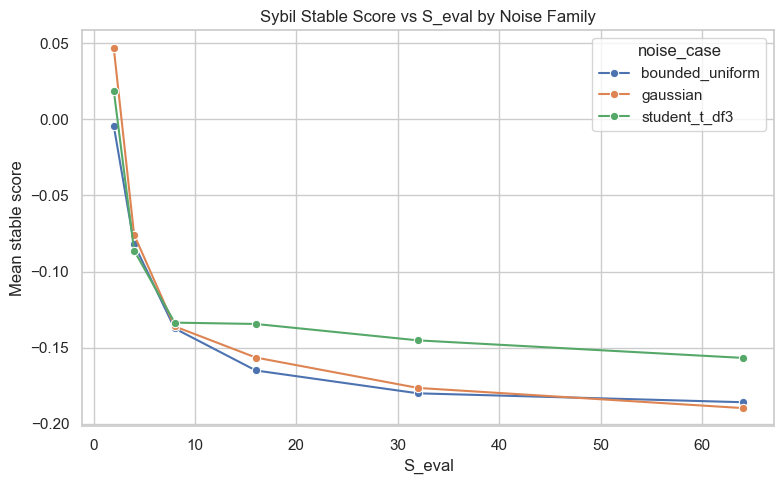

In [12]:
# Sybil-focused stable score under different noise families
sybil_summary = summary[summary['role'] == 'sybil'].copy()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=sybil_summary,
    x='s_eval', y='stable_score_mean',
    hue='noise_case', marker='o'
)
plt.title('Sybil Stable Score vs S_eval by Noise Family')
plt.xlabel('S_eval')
plt.ylabel('Mean stable score')
plt.tight_layout()
plt.show()